In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import roc_auc_score, roc_curve

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Torch: 2.12.0+cu126
CUDA available: True
CUDA version: 12.6
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using: cuda


In [2]:
PROCESSED_DIR = Path("processed")

paths = {
    "train": PROCESSED_DIR / "processed_jet_track_val.npz",
    "test_background": PROCESSED_DIR / "processed_jet_track_test_background.npz",
    "test_signal": PROCESSED_DIR / "processed_jet_track_test_signal.npz",
}

for name, path in paths.items():
    print(name, path, "exists:", path.exists())

train processed\processed_jet_track_val.npz exists: True
test_background processed\processed_jet_track_test_background.npz exists: True
test_signal processed\processed_jet_track_test_signal.npz exists: True


In [3]:
data_train = np.load(paths["train"], allow_pickle=True)
data_bg = np.load(paths["test_background"], allow_pickle=True)
data_sig = np.load(paths["test_signal"], allow_pickle=True)

print("Loaded.")
print("train keys:", list(data_train.keys()))

Loaded.
train keys: ['X_jets', 'X_tracks', 'track_mask', 'jet_feature_names', 'track_feature_names', 'y', 'meta_isDisplaced', 'meta_flavour_label', 'norm_jets_mean_pt', 'norm_jets_std_pt', 'norm_jets_mean_eta', 'norm_jets_std_eta', 'norm_jets_mean_mass', 'norm_jets_std_mass', 'norm_jets_mean_energy', 'norm_jets_std_energy', 'norm_jets_mean_displacedPtFraction', 'norm_jets_std_displacedPtFraction', 'norm_jets_mean_Qw_clusterSoftDrop', 'norm_jets_std_Qw_clusterSoftDrop', 'norm_jets_mean_C2_clusterSoftDrop', 'norm_jets_std_C2_clusterSoftDrop', 'norm_jets_mean_D2_clusterSoftDrop', 'norm_jets_std_D2_clusterSoftDrop', 'norm_jets_mean_Tau1_clusterSoftDrop', 'norm_jets_std_Tau1_clusterSoftDrop', 'norm_jets_mean_Tau2_clusterSoftDrop', 'norm_jets_std_Tau2_clusterSoftDrop', 'norm_jets_mean_Tau3_clusterSoftDrop', 'norm_jets_std_Tau3_clusterSoftDrop', 'norm_jets_mean_Tau21_clusterSoftDrop', 'norm_jets_std_Tau21_clusterSoftDrop', 'norm_jets_mean_Tau32_clusterSoftDrop', 'norm_jets_std_Tau32_clusterSo

In [4]:
def describe_npz(name, data):
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    X_jets = data["X_jets"]
    X_tracks = data["X_tracks"]
    mask = data["track_mask"]

    print("X_jets:", X_jets.shape, X_jets.dtype)
    print("X_tracks:", X_tracks.shape, X_tracks.dtype)
    print("track_mask:", mask.shape, mask.dtype)

    print("jet features:", list(data["jet_feature_names"]))
    print("track features:", list(data["track_feature_names"]))

    print("finite X_jets:", np.isfinite(X_jets).all())
    print("finite X_tracks:", np.isfinite(X_tracks).all())
    print("invalid tracks zero:", np.allclose(X_tracks[~mask], 0.0))

    if "y" in data:
        print("y:", np.unique(data["y"], return_counts=True))

    if "meta_isDisplaced" in data:
        print("meta_isDisplaced:", np.unique(data["meta_isDisplaced"], return_counts=True))


describe_npz("train/val", data_train)
describe_npz("test background", data_bg)
describe_npz("test signal", data_sig)


train/val
X_jets: (100000, 15) float32
X_tracks: (100000, 200, 12) float32
track_mask: (100000, 200) bool
jet features: ['pt', 'eta', 'mass', 'energy', 'displacedPtFraction', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']
track features: ['d0', 'z0SinTheta', 'dphi', 'deta', 'pt_log1p', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']
finite X_jets: True
finite X_tracks: True
invalid tracks zero: True
y: (array([0]), array([100000]))
meta_isDisplaced: (array([0], dtype=int32), array([100000]))

test background
X_jets: (100000, 15) float32
X_tracks: (100000, 200, 12) float32
track_mask: (100000, 200) bool
jet features: ['pt', 'eta', 'mass', 'energy', 'displacedPtFraction', 'Qw_clusterS

In [5]:
X_jets_train = data_train["X_jets"].astype(np.float32)
X_tracks_train = data_train["X_tracks"].astype(np.float32)
mask_train = data_train["track_mask"].astype(bool)

X_jets_bg = data_bg["X_jets"].astype(np.float32)
X_tracks_bg = data_bg["X_tracks"].astype(np.float32)
mask_bg = data_bg["track_mask"].astype(bool)

X_jets_sig = data_sig["X_jets"].astype(np.float32)
X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
mask_sig = data_sig["track_mask"].astype(bool)

jet_feature_names = list(data_train["jet_feature_names"])
track_feature_names = list(data_train["track_feature_names"])

print("Train jets:", X_jets_train.shape)
print("Train tracks:", X_tracks_train.shape)
print("Track features:", track_feature_names)
print("Jet features:", jet_feature_names)

Train jets: (100000, 15)
Train tracks: (100000, 200, 12)
Track features: ['d0', 'z0SinTheta', 'dphi', 'deta', 'pt_log1p', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']
Jet features: ['pt', 'eta', 'mass', 'energy', 'displacedPtFraction', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']


In [7]:
def aggregate_track_features(X_tracks, mask):
    features = []

    # Numero di tracce valide per jet
    n_valid = mask.sum(axis=1, keepdims=True).astype(np.float32)
    features.append(n_valid)

    for i in range(X_tracks.shape[-1]):
        vals = X_tracks[:, :, i]

        # metti NaN dove la traccia è padding
        valid_vals = np.where(mask, vals, np.nan)

        mean = np.nanmean(valid_vals, axis=1, keepdims=True)
        std = np.nanstd(valid_vals, axis=1, keepdims=True)
        median = np.nanmedian(valid_vals, axis=1, keepdims=True)
        q90 = np.nanpercentile(valid_vals, 90, axis=1, keepdims=True)
        maxv = np.nanmax(valid_vals, axis=1, keepdims=True)

        features.extend([mean, std, median, q90, maxv])

    out = np.concatenate(features, axis=1)
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    return out.astype(np.float32)

In [8]:
A_train_tracks = aggregate_track_features(X_tracks_train, mask_train)
A_bg_tracks = aggregate_track_features(X_tracks_bg, mask_bg)
A_sig_tracks = aggregate_track_features(X_tracks_sig, mask_sig)

A_train = np.concatenate([X_jets_train, A_train_tracks], axis=1)
A_bg = np.concatenate([X_jets_bg, A_bg_tracks], axis=1)
A_sig = np.concatenate([X_jets_sig, A_sig_tracks], axis=1)

print("A_train:", A_train.shape)
print("A_bg:", A_bg.shape)
print("A_sig:", A_sig.shape)

C:\Users\andre\AppData\Local\Temp\ipykernel_19600\1618912848.py:14: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(valid_vals, axis=1, keepdims=True)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\andre\AppData\Local\Temp\ipykernel_19600\1618912848.py:16: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(valid_vals, axis=1, keepdims=True)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\andre\AppData\Local\Temp\ipykernel_19600\1618912848.py:18: RuntimeWarning: All-NaN slice encountered
  maxv = np.nanmax(valid_vals, axis=1, keepdims=True)


A_train: (100000, 76)
A_bg: (100000, 76)
A_sig: (61966, 76)


In [9]:
aggregate_feature_names = []

aggregate_feature_names.extend(jet_feature_names)
aggregate_feature_names.append("n_valid_tracks")

for feat in track_feature_names:
    aggregate_feature_names.extend([
        f"{feat}_mean",
        f"{feat}_std",
        f"{feat}_median",
        f"{feat}_q90",
        f"{feat}_max",
    ])

print("Number of aggregate features:", len(aggregate_feature_names))
print("A_train features:", A_train.shape[1])

Number of aggregate features: 76
A_train features: 76


In [10]:
print("finite train:", np.isfinite(A_train).all())
print("finite bg:", np.isfinite(A_bg).all())
print("finite sig:", np.isfinite(A_sig).all())

finite train: True
finite bg: True
finite sig: True


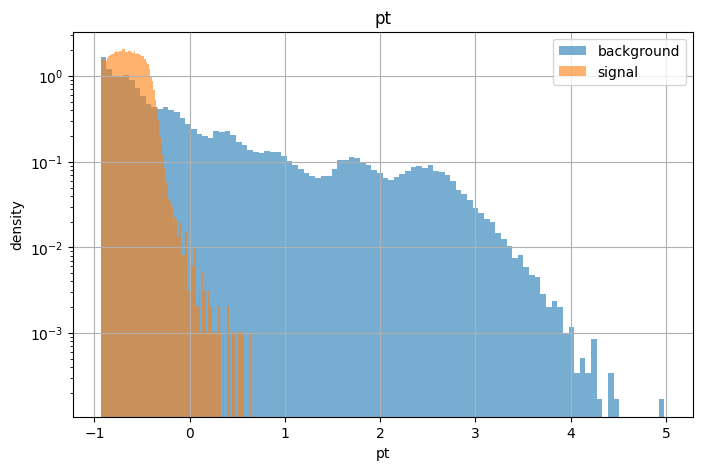

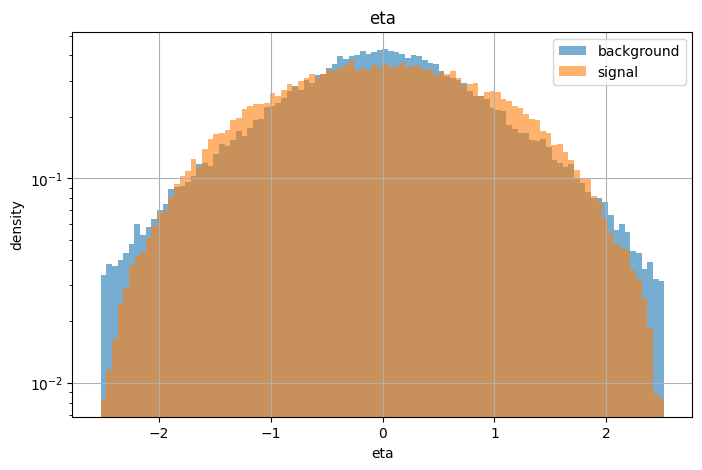

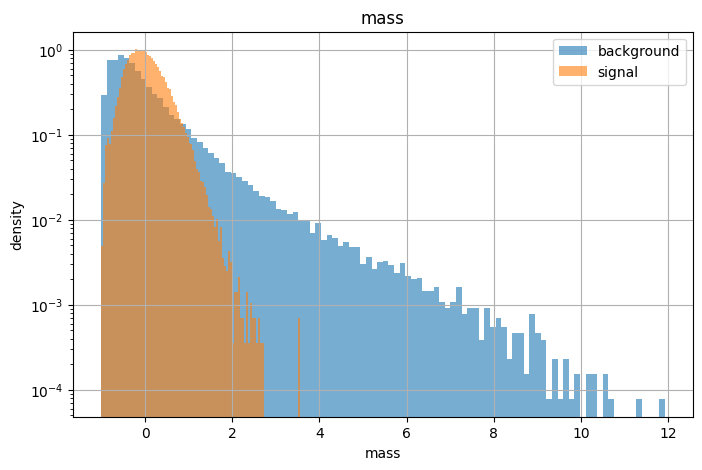

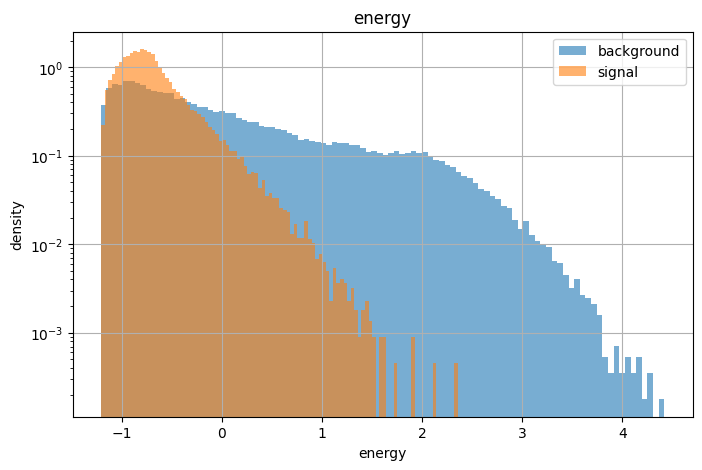

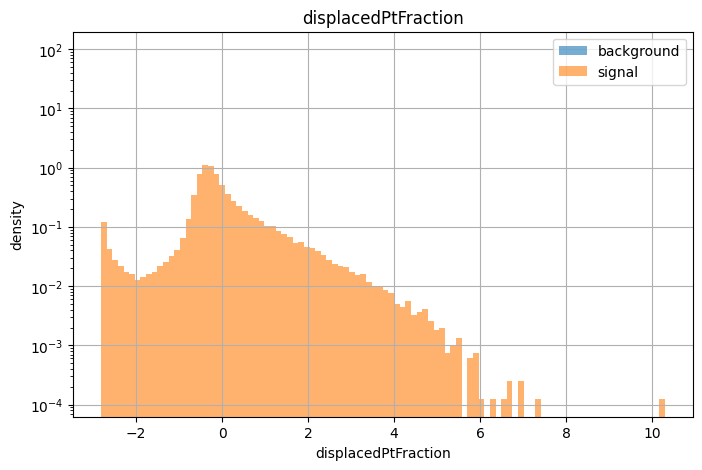

In [11]:
def plot_aggregate_feature(index):
    name = aggregate_feature_names[index]

    plt.figure(figsize=(8, 5))
    plt.hist(A_bg[:, index], bins=100, density=True, alpha=0.6, label="background")
    plt.hist(A_sig[:, index], bins=100, density=True, alpha=0.6, label="signal")
    plt.yscale("log")
    plt.xlabel(name)
    plt.ylabel("density")
    plt.title(name)
    plt.legend()
    plt.grid(True)
    plt.show()


# prime jet features
for i in range(min(5, A_bg.shape[1])):
    plot_aggregate_feature(i)

In [12]:
agg_mean = A_train.mean(axis=0, keepdims=True)
agg_std = A_train.std(axis=0, keepdims=True)
agg_std = np.maximum(agg_std, 1e-8)

A_train_norm = (A_train - agg_mean) / agg_std
A_bg_norm = (A_bg - agg_mean) / agg_std
A_sig_norm = (A_sig - agg_mean) / agg_std

A_train_norm = np.nan_to_num(A_train_norm, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
A_bg_norm = np.nan_to_num(A_bg_norm, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
A_sig_norm = np.nan_to_num(A_sig_norm, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

print("A_train_norm mean:", A_train_norm.mean())
print("A_train_norm std:", A_train_norm.std())

A_train_norm mean: -0.013169752
A_train_norm std: 0.99334115


In [13]:
class AggregateDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx]

In [14]:
full_dataset = AggregateDataset(A_train_norm)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

Train: 80000
Val: 20000


In [15]:
class AggregateAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

In [16]:
input_dim = A_train_norm.shape[1]
latent_dim = 16

model = AggregateAutoencoder(
    input_dim=input_dim,
    latent_dim=latent_dim,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

print(model)
print("input_dim:", input_dim)

AggregateAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=76, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=128, bias=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=76, bias=True)
  )
)
input_dim: 76


In [17]:
def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)

            reco = model(X_batch)
            loss = torch.mean((reco - X_batch) ** 2)

            total_loss += loss.item() * X_batch.shape[0]
            total_items += X_batch.shape[0]

    return total_loss / total_items

In [18]:
n_epochs = 600

train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.train()

    total_loss = 0.0
    total_items = 0

    for X_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        reco = model(X_batch)
        loss = torch.mean((reco - X_batch) ** 2)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.shape[0]
        total_items += X_batch.shape[0]

    avg_train_loss = total_loss / total_items
    avg_val_loss = evaluate_loss(model, val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1:02d}/{n_epochs} "
        f"| train loss = {avg_train_loss:.6f} "
        f"| val loss = {avg_val_loss:.6f}"
    )

Epoch 01/600 | train loss = 0.554246 | val loss = 0.354047
Epoch 02/600 | train loss = 0.308027 | val loss = 0.255894
Epoch 03/600 | train loss = 0.240312 | val loss = 0.218584
Epoch 04/600 | train loss = 0.213158 | val loss = 0.198155
Epoch 05/600 | train loss = 0.195271 | val loss = 0.183478
Epoch 06/600 | train loss = 0.182431 | val loss = 0.173305
Epoch 07/600 | train loss = 0.174262 | val loss = 0.166122
Epoch 08/600 | train loss = 0.167860 | val loss = 0.161861
Epoch 09/600 | train loss = 0.163708 | val loss = 0.157697
Epoch 10/600 | train loss = 0.159439 | val loss = 0.154092
Epoch 11/600 | train loss = 0.155829 | val loss = 0.150679
Epoch 12/600 | train loss = 0.153509 | val loss = 0.149737
Epoch 13/600 | train loss = 0.151263 | val loss = 0.146496
Epoch 14/600 | train loss = 0.148460 | val loss = 0.144879
Epoch 15/600 | train loss = 0.146937 | val loss = 0.141465
Epoch 16/600 | train loss = 0.144400 | val loss = 0.140602
Epoch 17/600 | train loss = 0.143318 | val loss = 0.1382

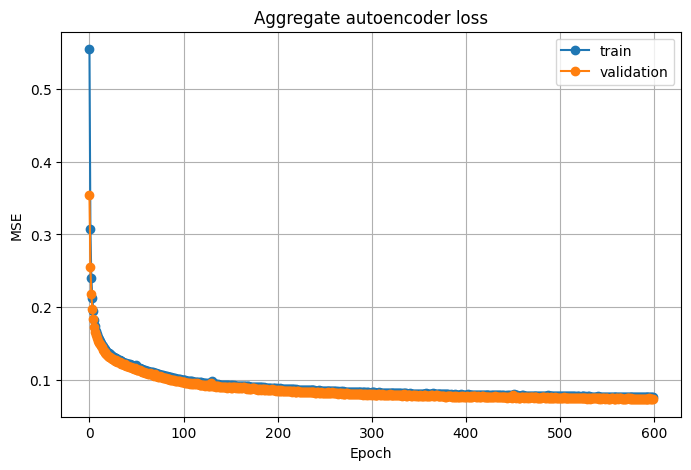

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker="o", label="train")
plt.plot(val_losses, marker="o", label="validation")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Aggregate autoencoder loss")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
def compute_scores(model, X, batch_size=2048):
    dataset = AggregateDataset(X)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()
    scores = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)

            reco = model(X_batch)
            score = torch.mean((reco - X_batch) ** 2, dim=1)

            scores.append(score.cpu().numpy())

    return np.concatenate(scores)

In [21]:
scores_bg = compute_scores(model, A_bg_norm)
scores_sig = compute_scores(model, A_sig_norm)

print("scores_bg:", scores_bg.shape)
print("scores_sig:", scores_sig.shape)

print("Background mean:", scores_bg.mean())
print("Signal mean:", scores_sig.mean())

print("Background median:", np.median(scores_bg))
print("Signal median:", np.median(scores_sig))

scores_bg: (100000,)
scores_sig: (61966,)
Background mean: 0.07470946
Signal mean: 1.363064e+14
Background median: 0.06509816
Signal median: 2.2041923e+13


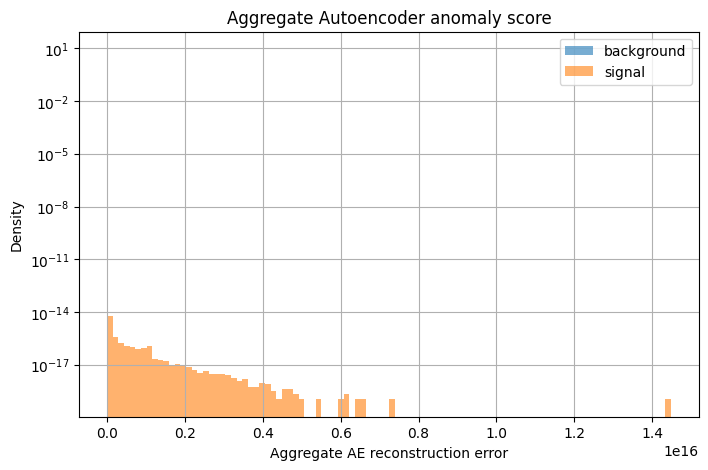

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(scores_bg, bins=100, density=True, alpha=0.6, label="background")
plt.hist(scores_sig, bins=100, density=True, alpha=0.6, label="signal")

plt.yscale("log")
plt.xlabel("Aggregate AE reconstruction error")
plt.ylabel("Density")
plt.title("Aggregate Autoencoder anomaly score")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
y_true = np.concatenate([
    np.zeros_like(scores_bg),
    np.ones_like(scores_sig),
])

y_score = np.concatenate([
    scores_bg,
    scores_sig,
])

auc = roc_auc_score(y_true, y_score)
auc_inv = roc_auc_score(y_true, -y_score)

print("AUC:", auc)
print("AUC inverted:", auc_inv)
print("Best AUC:", max(auc, auc_inv))

AUC: 1.0
AUC inverted: 0.0
Best AUC: 1.0


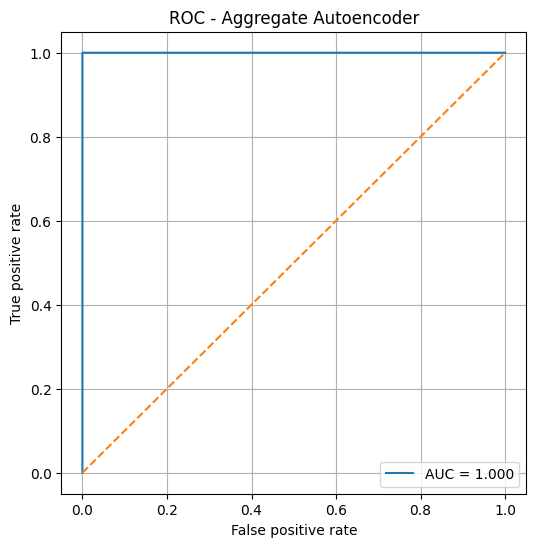

In [24]:
if auc_inv > auc:
    plot_score = -y_score
    label = f"AUC inverted = {auc_inv:.3f}"
else:
    plot_score = y_score
    label = f"AUC = {auc:.3f}"

fpr, tpr, thresholds = roc_curve(y_true, plot_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=label)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC - Aggregate Autoencoder")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "aggregate_feature_names": aggregate_feature_names,
        "input_dim": input_dim,
        "latent_dim": latent_dim,
        "agg_mean": agg_mean,
        "agg_std": agg_std,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "auc": auc,
        "auc_inv": auc_inv,
        "best_auc": max(auc, auc_inv),
    },
    OUT_DIR / "aggregate_autoencoder.pt",
)

np.savez_compressed(
    OUT_DIR / "aggregate_autoencoder_scores.npz",
    scores_bg=scores_bg,
    scores_sig=scores_sig,
    y_true=y_true,
    y_score=y_score,
    auc=np.array(auc, dtype=np.float32),
    auc_inv=np.array(auc_inv, dtype=np.float32),
    best_auc=np.array(max(auc, auc_inv), dtype=np.float32),
    aggregate_feature_names=np.array(aggregate_feature_names, dtype=object),
)

print("Saved model:", OUT_DIR / "aggregate_autoencoder.pt")
print("Saved scores:", OUT_DIR / "aggregate_autoencoder_scores.npz")

Saved model: outputs\aggregate_autoencoder.pt
Saved scores: outputs\aggregate_autoencoder_scores.npz


In [26]:
from sklearn.metrics import roc_auc_score
import pandas as pd

rows = []

for i, name in enumerate(aggregate_feature_names):
    bg = A_bg_norm[:, i]
    sig = A_sig_norm[:, i]

    y = np.concatenate([
        np.zeros_like(bg),
        np.ones_like(sig),
    ])

    x = np.concatenate([bg, sig])

    auc = roc_auc_score(y, x)
    auc_inv = roc_auc_score(y, -x)

    rows.append({
        "feature": name,
        "auc": auc,
        "auc_inverted": auc_inv,
        "best_auc": max(auc, auc_inv),
        "bg_mean": bg.mean(),
        "sig_mean": sig.mean(),
        "bg_median": np.median(bg),
        "sig_median": np.median(sig),
    })

df_feature_auc = pd.DataFrame(rows).sort_values("best_auc", ascending=False)
df_feature_auc.head(30)

,feature,auc,auc_inverted,best_auc,bg_mean,sig_mean,bg_median,sig_median
9,Tau2_clusterSoftDrop,0.873391,0.126609,0.873391,-0.006056,1.909880,-0.365344,1.804528
71,numberOfSCTSharedHits_mean,0.126630,0.873370,0.873370,0.006760,-1.130714,-0.160532,-1.241153
72,numberOfSCTSharedHits_std,0.144040,0.855960,0.855960,0.008131,-1.314940,-0.025107,-1.349235
10,Tau3_clusterSoftDrop,0.855943,0.144057,0.855943,-0.006813,1.737541,-0.372516,1.630374
8,Tau1_clusterSoftDrop,0.854401,0.145599,0.854401,-0.004039,1.569461,-0.374299,1.438372
61,numberOfInnermostPixelLayerHits_mean,0.151019,0.848981,0.848981,0.004433,-1.535786,0.003665,-1.629422
43,radiusOfFirstHit_median,0.844183,0.155817,0.844183,-0.006881,2.909894,-0.228970,1.537512
46,numberOfPixelHits_mean,0.168498,0.831502,0.831502,0.000057,-1.485804,0.003881,-1.548464
74,numberOfSCTSharedHits_q90,0.178773,0.821227,0.821227,0.003645,-1.133754,0.126552,-1.295439
6,C2_clusterSoftDrop,0.816851,0.183149,0.816851,0.000264,0.106824,0.111657,0.113672


Train score mean: 0.073044084
Background test score mean: 0.07470946
Signal score mean: 1.363064e+14
Train score median: 0.0645595
Background test score median: 0.06509816
Signal score median: 2.2041923e+13


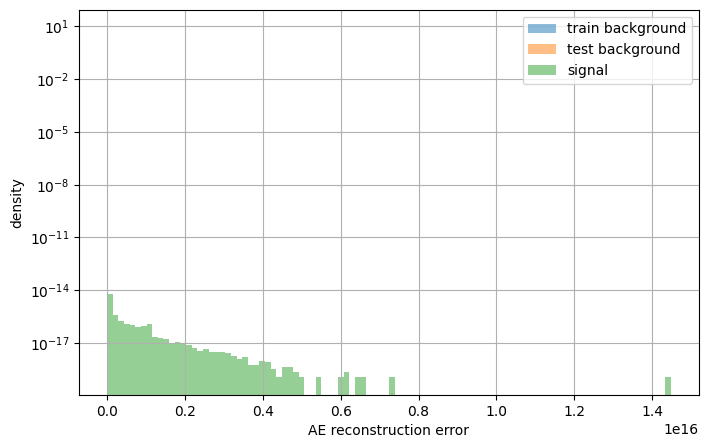

In [27]:
scores_train = compute_scores(model, A_train_norm)

print("Train score mean:", scores_train.mean())
print("Background test score mean:", scores_bg.mean())
print("Signal score mean:", scores_sig.mean())

print("Train score median:", np.median(scores_train))
print("Background test score median:", np.median(scores_bg))
print("Signal score median:", np.median(scores_sig))

plt.figure(figsize=(8, 5))

plt.hist(scores_train, bins=100, density=True, alpha=0.5, label="train background")
plt.hist(scores_bg, bins=100, density=True, alpha=0.5, label="test background")
plt.hist(scores_sig, bins=100, density=True, alpha=0.5, label="signal")

plt.yscale("log")
plt.xlabel("AE reconstruction error")
plt.ylabel("density")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
y_bg_check = np.concatenate([
    np.zeros_like(scores_train),
    np.ones_like(scores_bg),
])

s_bg_check = np.concatenate([
    scores_train,
    scores_bg,
])

auc_train_vs_testbg = roc_auc_score(y_bg_check, s_bg_check)
auc_train_vs_testbg_inv = roc_auc_score(y_bg_check, -s_bg_check)

print("AUC train vs test background:", auc_train_vs_testbg)
print("AUC inverted:", auc_train_vs_testbg_inv)
print("Best:", max(auc_train_vs_testbg, auc_train_vs_testbg_inv))

AUC train vs test background: 0.50784790105
AUC inverted: 0.49215209895
Best: 0.50784790105


### VAE

In [30]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import roc_auc_score, roc_curve

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Torch: 2.12.0+cu126
CUDA available: True
CUDA version: 12.6
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using: cuda


In [31]:
PROCESSED_DIR = Path("processed")

paths = {
    "train": PROCESSED_DIR / "processed_jet_track_val.npz",
    "test_background": PROCESSED_DIR / "processed_jet_track_test_background.npz",
    "test_signal": PROCESSED_DIR / "processed_jet_track_test_signal.npz",
}

for name, path in paths.items():
    print(name, path, "exists:", path.exists())

data_train = np.load(paths["train"], allow_pickle=True)
data_bg = np.load(paths["test_background"], allow_pickle=True)
data_sig = np.load(paths["test_signal"], allow_pickle=True)

train processed\processed_jet_track_val.npz exists: True
test_background processed\processed_jet_track_test_background.npz exists: True
test_signal processed\processed_jet_track_test_signal.npz exists: True


In [32]:
X_jets_train = data_train["X_jets"].astype(np.float32)
X_tracks_train = data_train["X_tracks"].astype(np.float32)
mask_train = data_train["track_mask"].astype(bool)

X_jets_bg = data_bg["X_jets"].astype(np.float32)
X_tracks_bg = data_bg["X_tracks"].astype(np.float32)
mask_bg = data_bg["track_mask"].astype(bool)

X_jets_sig = data_sig["X_jets"].astype(np.float32)
X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
mask_sig = data_sig["track_mask"].astype(bool)

jet_feature_names = list(data_train["jet_feature_names"])
track_feature_names = list(data_train["track_feature_names"])

print("Train:", X_jets_train.shape, X_tracks_train.shape)
print("Background:", X_jets_bg.shape, X_tracks_bg.shape)
print("Signal:", X_jets_sig.shape, X_tracks_sig.shape)

Train: (100000, 15) (100000, 200, 12)
Background: (100000, 15) (100000, 200, 12)
Signal: (61966, 15) (61966, 200, 12)


In [33]:
if "y" in data_train:
    train_bg_mask = data_train["y"] == 0
    print("Filtro training usando y == 0")
elif "meta_isDisplaced" in data_train:
    train_bg_mask = data_train["meta_isDisplaced"] == 0
    print("Filtro training usando meta_isDisplaced == 0")
else:
    train_bg_mask = np.ones(len(X_jets_train), dtype=bool)
    print("Nessuna label trovata: uso tutto il train")

print("Prima:", len(train_bg_mask))
print("Background-like:", train_bg_mask.sum())

X_jets_train = X_jets_train[train_bg_mask]
X_tracks_train = X_tracks_train[train_bg_mask]
mask_train = mask_train[train_bg_mask]

print("Dopo filtro:", X_jets_train.shape, X_tracks_train.shape)

Filtro training usando y == 0
Prima: 100000
Background-like: 100000
Dopo filtro: (100000, 15) (100000, 200, 12)


In [34]:
def aggregate_track_features(X_tracks, mask):
    features = []

    n_valid = mask.sum(axis=1, keepdims=True).astype(np.float32)
    features.append(n_valid)

    for i in range(X_tracks.shape[-1]):
        vals = X_tracks[:, :, i]
        valid_vals = np.where(mask, vals, np.nan)

        mean = np.nanmean(valid_vals, axis=1, keepdims=True)
        std = np.nanstd(valid_vals, axis=1, keepdims=True)
        median = np.nanmedian(valid_vals, axis=1, keepdims=True)
        q90 = np.nanpercentile(valid_vals, 90, axis=1, keepdims=True)
        maxv = np.nanmax(valid_vals, axis=1, keepdims=True)

        features.extend([mean, std, median, q90, maxv])

    out = np.concatenate(features, axis=1)
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    return out.astype(np.float32)

In [35]:
A_train_tracks = aggregate_track_features(X_tracks_train, mask_train)
A_bg_tracks = aggregate_track_features(X_tracks_bg, mask_bg)
A_sig_tracks = aggregate_track_features(X_tracks_sig, mask_sig)

A_train = np.concatenate([X_jets_train, A_train_tracks], axis=1)
A_bg = np.concatenate([X_jets_bg, A_bg_tracks], axis=1)
A_sig = np.concatenate([X_jets_sig, A_sig_tracks], axis=1)

print("A_train:", A_train.shape)
print("A_bg:", A_bg.shape)
print("A_sig:", A_sig.shape)

C:\Users\andre\AppData\Local\Temp\ipykernel_19600\4088229062.py:11: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(valid_vals, axis=1, keepdims=True)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\andre\AppData\Local\Temp\ipykernel_19600\4088229062.py:13: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(valid_vals, axis=1, keepdims=True)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\andre\AppData\Local\Temp\ipykernel_19600\4088229062.py:15: RuntimeWarning: All-NaN slice encountered
  maxv = np.nanmax(valid_vals, axis=1, keepdims=True)


A_train: (100000, 76)
A_bg: (100000, 76)
A_sig: (61966, 76)


In [36]:
aggregate_feature_names = []

aggregate_feature_names.extend(jet_feature_names)
aggregate_feature_names.append("n_valid_tracks")

for feat in track_feature_names:
    aggregate_feature_names.extend([
        f"{feat}_mean",
        f"{feat}_std",
        f"{feat}_median",
        f"{feat}_q90",
        f"{feat}_max",
    ])

print("n aggregate features:", len(aggregate_feature_names))
print("A_train dim:", A_train.shape[1])

n aggregate features: 76
A_train dim: 76


In [37]:
agg_mean = A_train.mean(axis=0, keepdims=True)
agg_std = A_train.std(axis=0, keepdims=True)
agg_std = np.maximum(agg_std, 1e-8)

A_train_norm = ((A_train - agg_mean) / agg_std).astype(np.float32)
A_bg_norm = ((A_bg - agg_mean) / agg_std).astype(np.float32)
A_sig_norm = ((A_sig - agg_mean) / agg_std).astype(np.float32)

A_train_norm = np.nan_to_num(A_train_norm, nan=0.0, posinf=0.0, neginf=0.0)
A_bg_norm = np.nan_to_num(A_bg_norm, nan=0.0, posinf=0.0, neginf=0.0)
A_sig_norm = np.nan_to_num(A_sig_norm, nan=0.0, posinf=0.0, neginf=0.0)

print("finite train:", np.isfinite(A_train_norm).all())
print("finite bg:", np.isfinite(A_bg_norm).all())
print("finite sig:", np.isfinite(A_sig_norm).all())

finite train: True
finite bg: True
finite sig: True


In [38]:
class AggregateDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx]

In [39]:
full_dataset = AggregateDataset(A_train_norm)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

Train: 80000
Val: 20000


In [40]:
class AggregateVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reco = self.decode(z)
        return reco, mu, logvar

In [41]:
def vae_loss(reco, x, mu, logvar, beta=1e-3):
    reco_loss = torch.mean((reco - x) ** 2)

    kl_per_sample = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp(),
        dim=1,
    )

    kl_loss = torch.mean(kl_per_sample)

    total_loss = reco_loss + beta * kl_loss

    return total_loss, reco_loss, kl_loss

In [42]:
input_dim = A_train_norm.shape[1]
latent_dim = 16
beta = 1e-3

model = AggregateVAE(
    input_dim=input_dim,
    latent_dim=latent_dim,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

print(model)
print("input_dim:", input_dim)
print("latent_dim:", latent_dim)
print("beta:", beta)

AggregateVAE(
  (encoder): Sequential(
    (0): Linear(in_features=76, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=128, bias=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=76, bias=True)
  )
)
input_dim: 76
latent_dim: 16

In [43]:
def evaluate_vae_loss(model, loader, beta=1e-3):
    model.eval()

    total_loss = 0.0
    total_reco = 0.0
    total_kl = 0.0
    total_items = 0

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)

            reco, mu, logvar = model(X_batch)
            loss, reco_loss, kl_loss = vae_loss(
                reco,
                X_batch,
                mu,
                logvar,
                beta=beta,
            )

            bs = X_batch.shape[0]
            total_loss += loss.item() * bs
            total_reco += reco_loss.item() * bs
            total_kl += kl_loss.item() * bs
            total_items += bs

    return (
        total_loss / total_items,
        total_reco / total_items,
        total_kl / total_items,
    )

In [44]:
n_epochs = 600

train_losses = []
train_reco_losses = []
train_kl_losses = []

val_losses = []
val_reco_losses = []
val_kl_losses = []

for epoch in range(n_epochs):
    model.train()

    total_loss = 0.0
    total_reco = 0.0
    total_kl = 0.0
    total_items = 0

    for X_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        reco, mu, logvar = model(X_batch)
        loss, reco_loss, kl_loss = vae_loss(
            reco,
            X_batch,
            mu,
            logvar,
            beta=beta,
        )

        loss.backward()
        optimizer.step()

        bs = X_batch.shape[0]
        total_loss += loss.item() * bs
        total_reco += reco_loss.item() * bs
        total_kl += kl_loss.item() * bs
        total_items += bs

    avg_train_loss = total_loss / total_items
    avg_train_reco = total_reco / total_items
    avg_train_kl = total_kl / total_items

    avg_val_loss, avg_val_reco, avg_val_kl = evaluate_vae_loss(
        model,
        val_loader,
        beta=beta,
    )

    train_losses.append(avg_train_loss)
    train_reco_losses.append(avg_train_reco)
    train_kl_losses.append(avg_train_kl)

    val_losses.append(avg_val_loss)
    val_reco_losses.append(avg_val_reco)
    val_kl_losses.append(avg_val_kl)

    print(
        f"Epoch {epoch+1:02d}/{n_epochs} | "
        f"train={avg_train_loss:.6f} "
        f"reco={avg_train_reco:.6f} "
        f"kl={avg_train_kl:.6f} | "
        f"val={avg_val_loss:.6f} "
        f"val_reco={avg_val_reco:.6f} "
        f"val_kl={avg_val_kl:.6f}"
    )

Epoch 01/600 | train=0.708984 reco=0.698060 kl=10.924718 | val=0.499580 val_reco=0.481317 val_kl=18.262795
Epoch 02/600 | train=0.438893 reco=0.415128 kl=23.765607 | val=0.370552 val_reco=0.343158 val_kl=27.393294
Epoch 03/600 | train=0.340415 reco=0.310152 kl=30.263020 | val=0.304702 val_reco=0.272343 val_kl=32.358997
Epoch 04/600 | train=0.291686 reco=0.258441 kl=33.244998 | val=0.267263 val_reco=0.233188 val_kl=34.074857
Epoch 05/600 | train=0.260183 reco=0.225484 kl=34.698976 | val=0.244802 val_reco=0.209737 val_kl=35.065423
Epoch 06/600 | train=0.241589 reco=0.206030 kl=35.558541 | val=0.231203 val_reco=0.195491 val_kl=35.711985
Epoch 07/600 | train=0.229802 reco=0.193929 kl=35.873682 | val=0.220323 val_reco=0.184153 val_kl=36.169773
Epoch 08/600 | train=0.221141 reco=0.185063 kl=36.077670 | val=0.213764 val_reco=0.177364 val_kl=36.399438
Epoch 09/600 | train=0.214383 reco=0.178142 kl=36.241449 | val=0.207676 val_reco=0.170777 val_kl=36.899097
Epoch 10/600 | train=0.208592 reco=0.

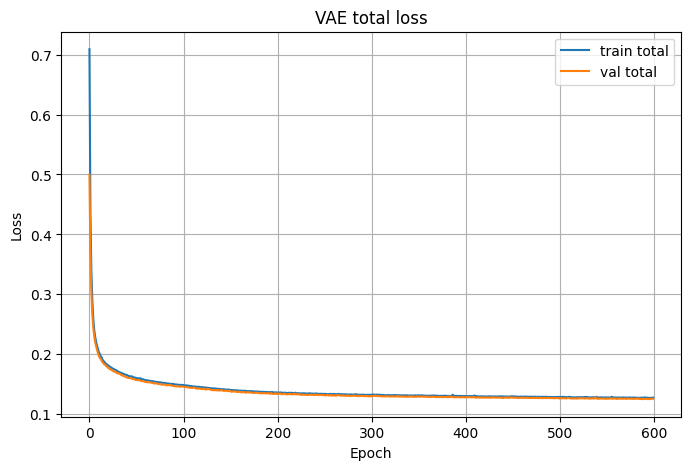

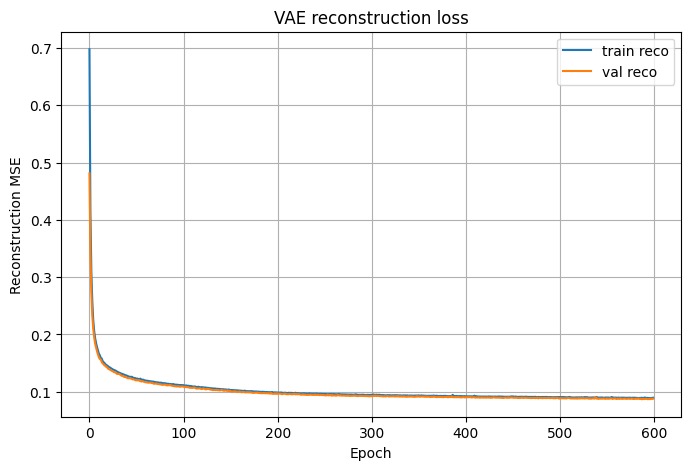

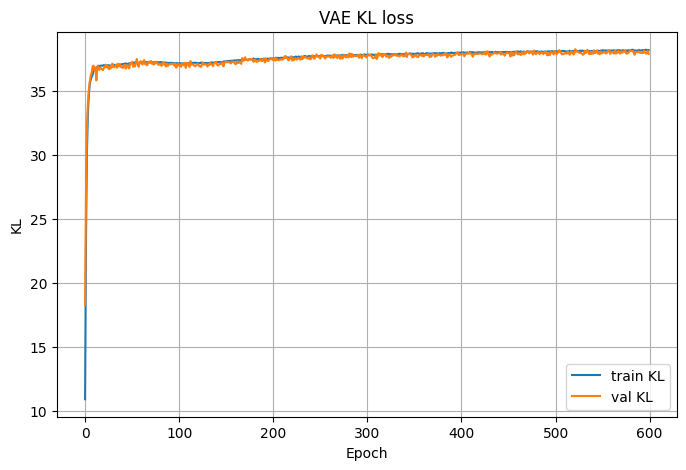

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="train total")
plt.plot(val_losses, label="val total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE total loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_reco_losses, label="train reco")
plt.plot(val_reco_losses, label="val reco")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction MSE")
plt.title("VAE reconstruction loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_kl_losses, label="train KL")
plt.plot(val_kl_losses, label="val KL")
plt.xlabel("Epoch")
plt.ylabel("KL")
plt.title("VAE KL loss")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
def compute_vae_scores(model, X, batch_size=2048, beta=1e-3):
    dataset = AggregateDataset(X)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()

    reco_scores = []
    kl_scores = []
    total_scores = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)

            reco, mu, logvar = model(X_batch)

            reco_score = torch.mean((reco - X_batch) ** 2, dim=1)

            kl_score = -0.5 * torch.sum(
                1 + logvar - mu.pow(2) - logvar.exp(),
                dim=1,
            )

            total_score = reco_score + beta * kl_score

            reco_scores.append(reco_score.cpu().numpy())
            kl_scores.append(kl_score.cpu().numpy())
            total_scores.append(total_score.cpu().numpy())

    return (
        np.concatenate(reco_scores),
        np.concatenate(kl_scores),
        np.concatenate(total_scores),
    )

In [47]:
scores_bg_reco, scores_bg_kl, scores_bg_total = compute_vae_scores(
    model,
    A_bg_norm,
    beta=beta,
)

scores_sig_reco, scores_sig_kl, scores_sig_total = compute_vae_scores(
    model,
    A_sig_norm,
    beta=beta,
)

print("Reco mean bg/sig:", scores_bg_reco.mean(), scores_sig_reco.mean())
print("KL mean bg/sig:", scores_bg_kl.mean(), scores_sig_kl.mean())
print("Total mean bg/sig:", scores_bg_total.mean(), scores_sig_total.mean())

Reco mean bg/sig: 0.0896384 1.3324268e+14
KL mean bg/sig: 37.9511 1.4447148e+13
Total mean bg/sig: 0.1275895 1.3325713e+14


In [48]:
def evaluate_scores(bg_scores, sig_scores, title):
    y_true = np.concatenate([
        np.zeros_like(bg_scores),
        np.ones_like(sig_scores),
    ])

    y_score = np.concatenate([
        bg_scores,
        sig_scores,
    ])

    auc = roc_auc_score(y_true, y_score)
    auc_inv = roc_auc_score(y_true, -y_score)
    best_auc = max(auc, auc_inv)

    print("\n" + title)
    print("AUC:", auc)
    print("AUC inverted:", auc_inv)
    print("Best AUC:", best_auc)

    if auc_inv > auc:
        plot_score = -y_score
        label = f"AUC inverted = {auc_inv:.3f}"
    else:
        plot_score = y_score
        label = f"AUC = {auc:.3f}"

    fpr, tpr, thresholds = roc_curve(y_true, plot_score)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=label)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return auc, auc_inv, best_auc


VAE reconstruction score
AUC: 1.0
AUC inverted: 0.0
Best AUC: 1.0


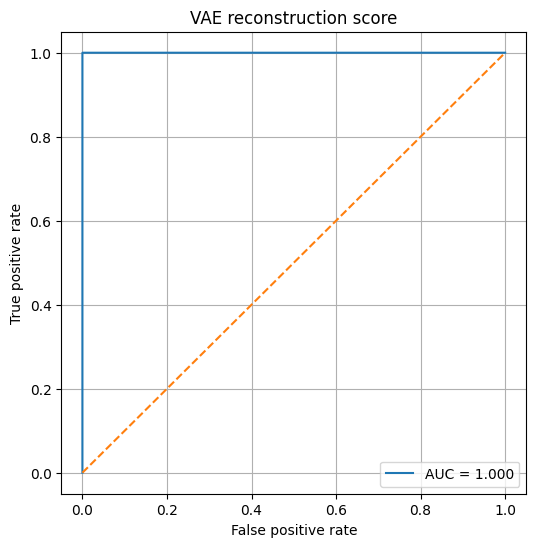


VAE KL score
AUC: 0.9999999998386212
AUC inverted: 1.613788206428443e-10
Best AUC: 0.9999999998386212


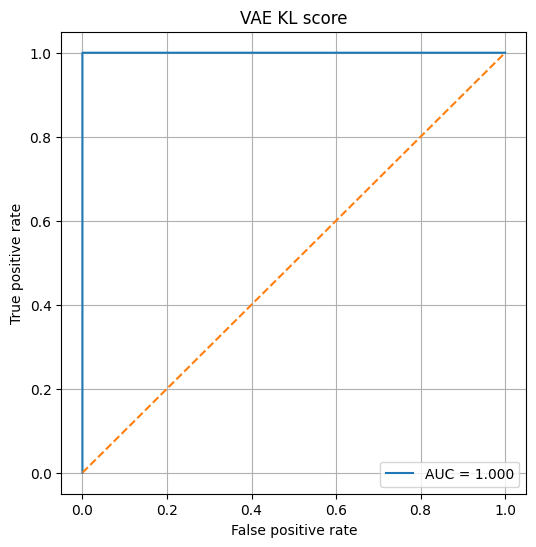


VAE total score
AUC: 1.0
AUC inverted: 0.0
Best AUC: 1.0


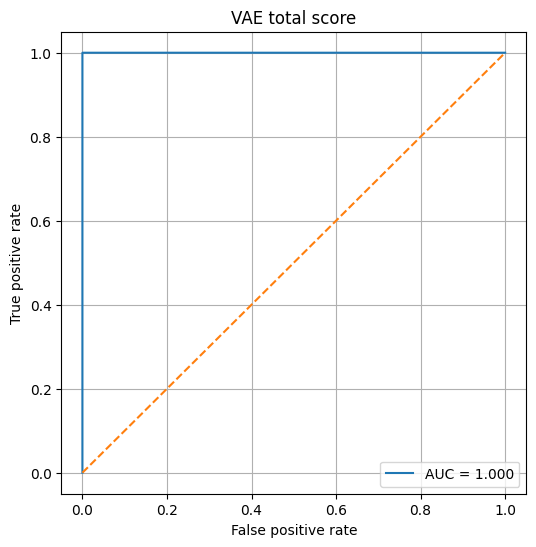

In [49]:
auc_reco, auc_reco_inv, best_auc_reco = evaluate_scores(
    scores_bg_reco,
    scores_sig_reco,
    "VAE reconstruction score",
)

auc_kl, auc_kl_inv, best_auc_kl = evaluate_scores(
    scores_bg_kl,
    scores_sig_kl,
    "VAE KL score",
)

auc_total, auc_total_inv, best_auc_total = evaluate_scores(
    scores_bg_total,
    scores_sig_total,
    "VAE total score",
)

In [50]:
def plot_score_distribution(bg_scores, sig_scores, title):
    plt.figure(figsize=(8, 5))

    plt.hist(bg_scores, bins=100, density=True, alpha=0.6, label="background")
    plt.hist(sig_scores, bins=100, density=True, alpha=0.6, label="signal")

    plt.yscale("log")
    plt.xlabel("score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

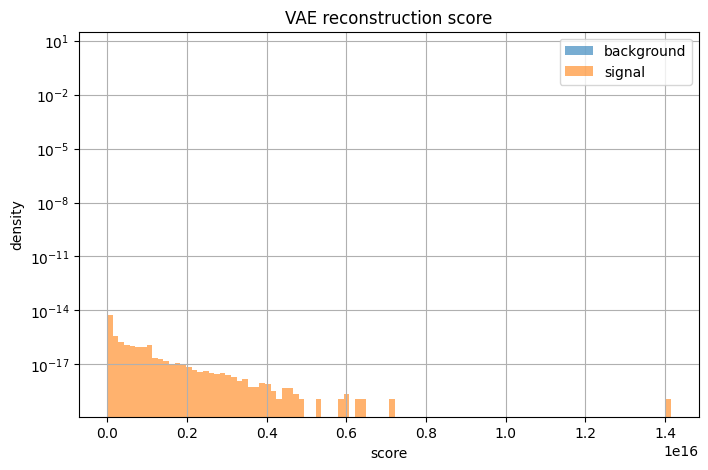

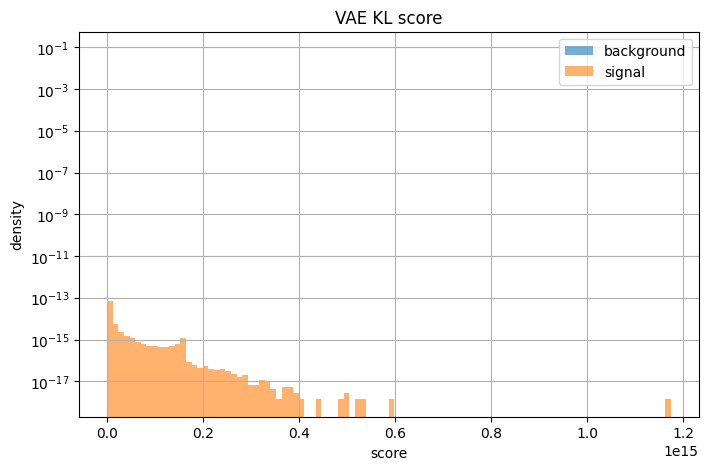

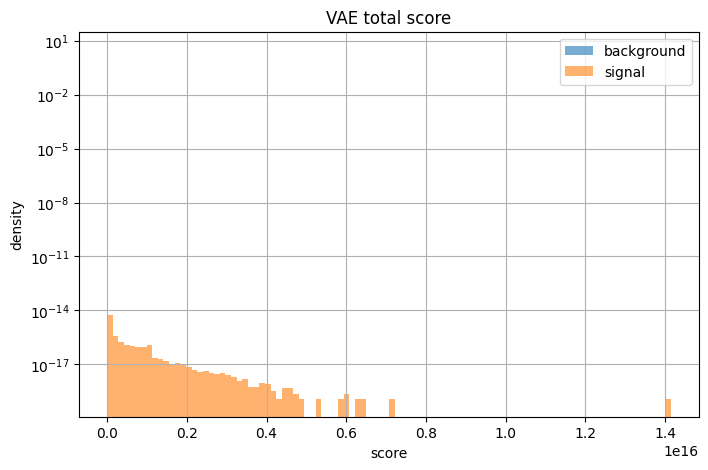

In [51]:
plot_score_distribution(
    scores_bg_reco,
    scores_sig_reco,
    "VAE reconstruction score",
)

plot_score_distribution(
    scores_bg_kl,
    scores_sig_kl,
    "VAE KL score",
)

plot_score_distribution(
    scores_bg_total,
    scores_sig_total,
    "VAE total score",
)

In [52]:
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "aggregate_feature_names": aggregate_feature_names,
        "input_dim": input_dim,
        "latent_dim": latent_dim,
        "beta": beta,
        "agg_mean": agg_mean,
        "agg_std": agg_std,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_auc_reco": best_auc_reco,
        "best_auc_kl": best_auc_kl,
        "best_auc_total": best_auc_total,
    },
    OUT_DIR / "aggregate_vae.pt",
)

np.savez_compressed(
    OUT_DIR / "aggregate_vae_scores.npz",
    scores_bg_reco=scores_bg_reco,
    scores_sig_reco=scores_sig_reco,
    scores_bg_kl=scores_bg_kl,
    scores_sig_kl=scores_sig_kl,
    scores_bg_total=scores_bg_total,
    scores_sig_total=scores_sig_total,
    auc_reco=np.array(auc_reco, dtype=np.float32),
    auc_reco_inv=np.array(auc_reco_inv, dtype=np.float32),
    best_auc_reco=np.array(best_auc_reco, dtype=np.float32),
    auc_kl=np.array(auc_kl, dtype=np.float32),
    auc_kl_inv=np.array(auc_kl_inv, dtype=np.float32),
    best_auc_kl=np.array(best_auc_kl, dtype=np.float32),
    auc_total=np.array(auc_total, dtype=np.float32),
    auc_total_inv=np.array(auc_total_inv, dtype=np.float32),
    best_auc_total=np.array(best_auc_total, dtype=np.float32),
    aggregate_feature_names=np.array(aggregate_feature_names, dtype=object),
)

print("Saved model:", OUT_DIR / "aggregate_vae.pt")
print("Saved scores:", OUT_DIR / "aggregate_vae_scores.npz")

Saved model: outputs\aggregate_vae.pt
Saved scores: outputs\aggregate_vae_scores.npz
